SQl56lauKekmdvLK9IJmgGMMxBbjHpUx

In [16]:
!pip install -q --upgrade --force-reinstall mistralai networkx matplotlib

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.27.1 requires opentelemetry-api<1.39.0,>=1.36.0, but you have opentelemetry-api 1.39.1 which is incompatible.
opentelemetry-sdk 1.38.0 requires opentelemetry-api==1.38.0, but you have opentelemetry-api 1.39.1 which is incompatible.
opentelemetry-sdk 1.38.0 requires opentelemetry-semantic-conventions==0.59b0, but you have opentelemetry-semantic-conventions 0.60b1 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.3 which is incompatible.
gradio 5.50.0 requires pillow<12.0,>=8.0, but you have pillow 12.1.1 which is incompatible.
gradio 5.50.0 requires pydantic<=2.12.3,>=2.0, but you have pydantic 2.12.5 which is incompatible.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.4.3 which is incompatible.


In [17]:
# @title 1. System Setup & Mistral "Brain" (Run this first)

import json
import networkx as nx
import matplotlib.pyplot as plt
from mistralai.client import Mistral
from google.colab import userdata

# 1. API SETUP
try:
    API_KEY = userdata.get("api-key")
    if not API_KEY:
        raise ValueError("API key not found in Colab userdata.")

    client = Mistral(api_key=API_KEY)
    MODEL_ID = "mistral-small-latest"

    # Test connection
    test = client.chat.complete(
        model=MODEL_ID,
        messages=[{"role": "user", "content": "Hello"}],
        response_format={"type": "text"}
    )
    print(f"Connected to Mistral! Response: {test.choices[0].message.content}")

except Exception as e:
    raise Exception(f"Connection failed: {e}")

# 2. DEFINE THE SYSTEM
class KnowledgeGraphAutofiller:
    def __init__(self, client, model):
        self.client = client
        self.model = model
        self.graph = nx.DiGraph()

    def visualize_graph(self, title="Knowledge Graph"):
        if self.graph.number_of_nodes() == 0:
            print("Graph is empty.")
            return

        plt.figure(figsize=(12, 8))
        pos = nx.spring_layout(self.graph, seed=42, k=0.8)

        nx.draw_networkx_nodes(
            self.graph, pos,
            node_size=1500,
            node_color="#ffcc99",
            edgecolors="#cc6600"
        )
        nx.draw_networkx_labels(self.graph, pos, font_size=9, font_weight="bold")

        nx.draw_networkx_edges(
            self.graph, pos,
            width=1.5,
            alpha=0.6,
            edge_color="gray",
            arrowsize=20
        )
        edge_labels = nx.get_edge_attributes(self.graph, "relationship")
        nx.draw_networkx_edge_labels(
            self.graph, pos,
            edge_labels=edge_labels,
            font_color="darkred",
            font_size=8
        )

        plt.title(title)
        plt.axis("off")
        plt.show()

    def _call_api(self, prompt):
        """Helper to handle Mistral API calls and JSON parsing"""
        try:
            response = self.client.chat.complete(
                model=self.model,
                messages=[{"role": "user", "content": prompt}],
                temperature=0,
                response_format={"type": "json_object"}
            )
            text = response.choices[0].message.content.strip()
            return json.loads(text)
        except Exception as e:
            print(f"API/JSON Error: {e}")
            return {}

    def learn_from_form(self, form_data, context="General Info"):
        print(f"Learning from form: {context}...")

        prompt = f"""
        You are a Knowledge Graph Architect.
        Extract entities and relationships from this form data.

        Data: {json.dumps(form_data)}
        Context: {context}

        Return a JSON object with a key "triples" containing a list:
        {{
            "triples": [
                {{"head": "Entity1", "relation": "RELATION", "tail": "Entity2"}}
            ]
        }}
        Use canonical names.
        'User' is the central node.
        """

        result = self._call_api(prompt)
        triples = result.get("triples", [])

        if triples:
            for t in triples:
                self.graph.add_edge(t["head"], t["tail"], relationship=t["relation"])
            print(f"Learned {len(triples)} new facts.")
        else:
            print("No data learned.")

    def autofill_form(self, form_fields):
        print(f"Autofilling fields: {form_fields}")

        graph_context = [
            f"({u}) -[{d['relationship']}]-> ({v})"
            for u, v, d in self.graph.edges(data=True)
        ]

        prompt = f"""
        You are an Autofill Agent.

        QUERY: Fill these form fields: {json.dumps(form_fields)}
        KNOWLEDGE: {json.dumps(graph_context)}

        INSTRUCTIONS:
        Map form labels to knowledge graph nodes.
        Infer if necessary.
        Return "NULL" if unknown.

        Return JSON:
        {{
            "Field_Label": "Filled_Value"
        }}
        """

        return self._call_api(prompt)

# Initialize System
bot = KnowledgeGraphAutofiller(client, MODEL_ID)
print("System ready.")

Connected to Mistral! Response: Hello! How can I assist you today? 😊
System ready.


In [ ]:
!pip install -q --upgrade mistralai networkx matplotlib

Learning from form: User Profile Setup...
Learned 5 new facts.


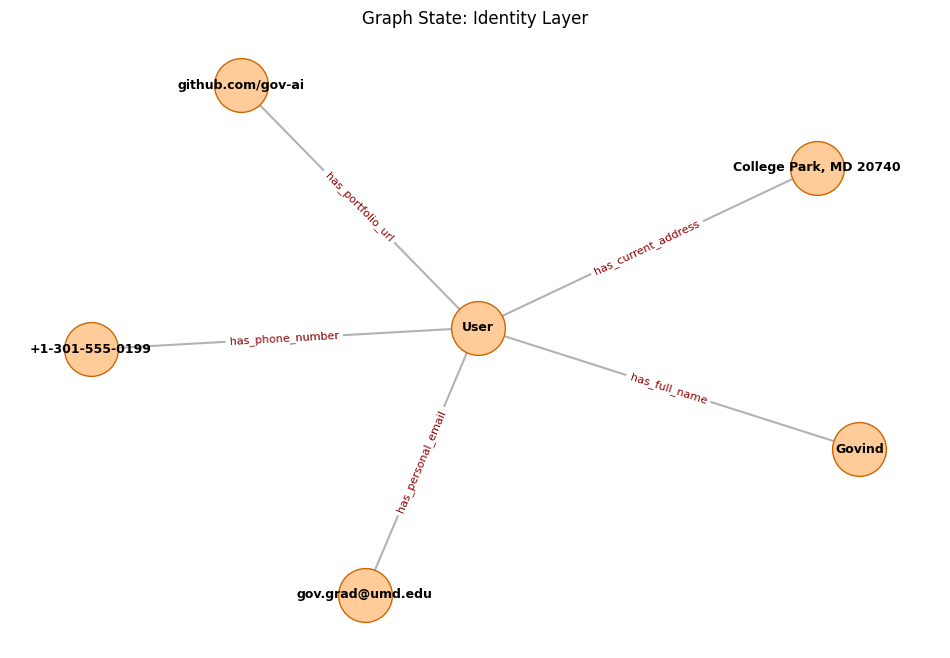

In [ ]:
# @title 2. Phase 1: User Identity (Hardcoded)
profile_data = {
    "Full Name": "Govind",
    "Personal Email": "gov.grad@umd.edu",
    "Phone Number": "+1-301-555-0199",
    "Current Address": "College Park, MD 20740",
    "Portfolio URL": "github.com/gov-ai"
}

# The system "learns" from this input
bot.learn_from_form(profile_data, context="User Profile Setup")

# Visualize the graph
bot.visualize_graph("Graph State: Identity Layer")

Learning from form: Academic Record...
Learned 8 new facts.


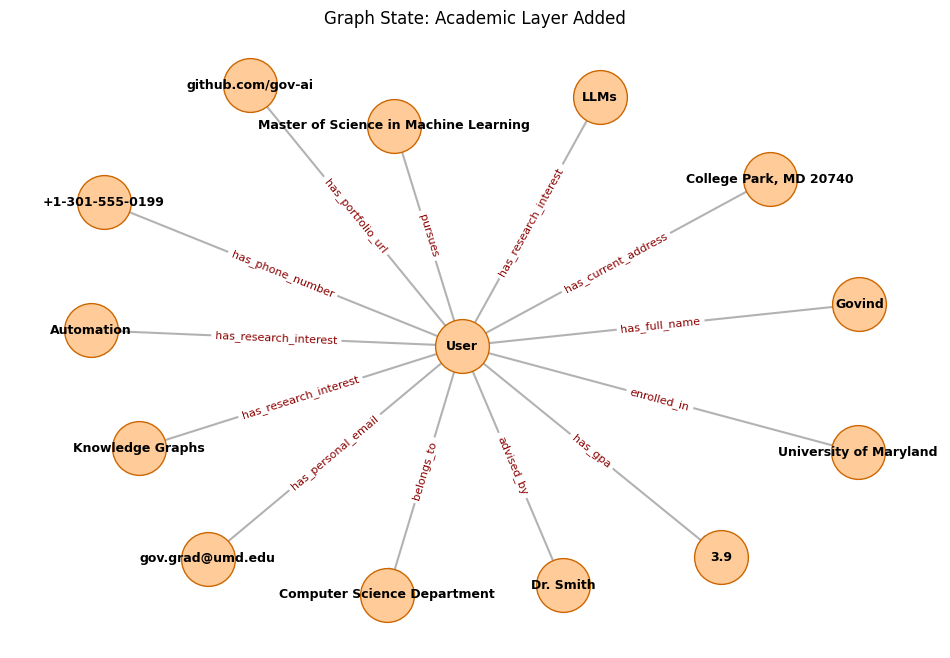

In [ ]:
# @title 3. Phase 2: Academic Info (Hardcoded)
academic_data = {
    "University Name": "University of Maryland",
    "Department": "Computer Science",
    "Degree Program": "Master of Science in Machine Learning",
    "Faculty Advisor": "Dr. Smith",
    "GPA": "3.9",
    "Research Interests": "Knowledge Graphs, LLMs, Automation"
}

# The system learns and links this to 'User'
bot.learn_from_form(academic_data, context="Academic Record")

# Visualize the expanded graph
bot.visualize_graph("Graph State: Academic Layer Added")

In [ ]:
# @title 4. Autofill Test: Job Application Form
# A new form appears with different labels
job_application_fields = [
    "Candidate Name",
    "Contact Email",
    "Current Residency",
    "Degree Pursuing",
    "Tech Interests"
]

# Run the Agent
results = bot.autofill_form(job_application_fields)

# Display Results
print("\n--- 📝 FORM RESULTS ---")
for label, value in results.items():
    print(f"📋 '{label}' -> AI filled: '{value}'")

Autofilling fields: ['Candidate Name', 'Contact Email', 'Current Residency', 'Degree Pursuing', 'Tech Interests']

--- 📝 FORM RESULTS ---
📋 'Candidate Name' -> AI filled: 'Govind'
📋 'Contact Email' -> AI filled: 'gov.grad@umd.edu'
📋 'Current Residency' -> AI filled: 'College Park, MD 20740'
📋 'Degree Pursuing' -> AI filled: 'Master of Science in Machine Learning'
📋 'Tech Interests' -> AI filled: 'Knowledge Graphs, LLMs, Automation'


In [ ]:
# @title 5. Stress Test: Inference, Missing Data & Generative Writing
# We ask for:
# 1. Inference (State from City)
# 2. Missing Data (Passport)
# 3. GENERATION (Write a bio based on 'Research Interests')

complex_form = [
    "Residency State",                       # Inference needed (MD)
    "Passport Number",                       # Missing data (Should be NULL)
    "Professional Summary (Write 50 words)"  # GENERATIVE TASK
]

print(f"🤖 tackling complex form: {complex_form}...\n")

# Run the Agent
results = bot.autofill_form(complex_form)

# Display Results with clear formatting
print("\n--- 🧠 INTELLIGENCE CHECK ---")
for label, value in results.items():
    if label == "Professional Summary (Write 50 words)":
        print(f"\n✨ GENERATIVE WRITING ({label}):")
        print(f"📝 \"{value}\"")
    else:
        status = "✅ Found/Inferred" if value != "NULL" else "🛡️ Correctly Missing"
        print(f"🔹 '{label}' -> '{value}' ({status})")

🤖 tackling complex form: ['Residency State', 'Passport Number', 'Professional Summary (Write 50 words)']...

Autofilling fields: ['Residency State', 'Passport Number', 'Professional Summary (Write 50 words)']

--- 🧠 INTELLIGENCE CHECK ---
🔹 'Residency State' -> 'Maryland' (✅ Found/Inferred)
🔹 'Passport Number' -> 'NULL' (🛡️ Correctly Missing)

✨ GENERATIVE WRITING (Professional Summary (Write 50 words)):
📝 "Computer Science graduate pursuing a Master of Science in Machine Learning with a 3.9 GPA. Skilled in Knowledge Graphs, LLMs, and Automation. Experienced researcher advised by Dr. Smith. Passionate about leveraging AI to solve real-world problems. Active contributor to open-source projects on GitHub."
